# 06 - Alternative Strategies and Final Scoreboard

**Inertia v2 - Factor Regimes** - Sprint 3 extension

The pure ensemble (long-short timing of every factor) loses to static FF5 because A/B/C edges are highly correlated. We explore alternative weight rules that defer to static while letting the regime signals operate at the margin. The goal is a strategy that *improves* risk-adjusted returns over static, even if modestly.

Variants tested:
1. **Long-only ensemble** (no shorts)
2. **Static + small tilt** (`w_i = 1/N + alpha * (p_i - 0.5)`)
3. **Top-K cross-sectional** (hold top K factors by P)
4. **Defensive shield** (binary, drop a factor when below threshold)
5. **Hybrid** (blend of static and ensemble pure timing)

Headline finding: **a 50/50 blend of static FF5 and Method C (GBM)** delivers the best risk-adjusted performance: Sharpe 0.80 vs static 0.74, with vol cut roughly in half and max drawdown nearly halved.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib.data import build_factor_panel, FF5_FACTORS
from lib.evaluation import perf_stats, perf_table, sharpe_bootstrap_ci, sharpe_diff_ci
from lib.style import (
    apply_style, save_fig, save_table,
    C, FACTOR_PALETTE, FULL_COL,
    yearly_xticks, legend_below, bar_value_labels,
)

apply_style()
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
FIG_DIR, TABLE_DIR = '../figures', '../tables'

## 1. Load probabilities and build benchmark + pure timed strategies

In [2]:
panel = build_factor_panel(include_macro=False)
P_A = pd.read_csv(f'{TABLE_DIR}/05_method_a_probs.csv', index_col=0, parse_dates=True)
P_B = pd.read_csv(f'{TABLE_DIR}/09_method_b_probs.csv', index_col=0, parse_dates=True)
P_C = pd.read_csv(f'{TABLE_DIR}/13_method_c_probs.csv', index_col=0, parse_dates=True)
common = P_A.index.intersection(P_B.index).intersection(P_C.index)
P_A, P_B, P_C = P_A.loc[common], P_B.loc[common], P_C.loc[common]
P_ens = (P_A + P_B + P_C) / 3.0

static_df = pd.DataFrame({f: panel[f].shift(-1).reindex(common) for f in FF5_FACTORS}).dropna(how='all')
r_static = static_df.mean(axis=1)
r_next = static_df

def pure(P, mode='linear'):
    if mode == 'linear':
        w = (2 * P - 1).clip(-1, 1)
    else:
        w = ((P - 0.5) * 4).clip(-1, 1)
    return (w * r_next).mean(axis=1)

r_pure_A = pure(P_A)
r_pure_B = pure(P_B, mode='soft')
r_pure_C = pure(P_C)
r_pure_E = pure(P_ens)

print(f'OOS sample: {len(common)} months, {common.min().date()} to {common.max().date()}')

OOS sample: 433 months, 1990-01-31 to 2026-01-31


## 2. Variant grid search

Test the five families of weight rules described above. For each variant, compute Sharpe and the paired bootstrap difference vs static.

In [3]:
def tilt(P, alpha):
    w = 1.0/5 + alpha * (P - 0.5)
    w = w.clip(lower=0)
    w = w.div(w.sum(axis=1), axis=0)
    return (w * r_next).sum(axis=1)

def topk(P, K):
    rank = P.rank(axis=1, ascending=False)
    w = (rank <= K).astype(float).div(K)
    return (w * r_next).sum(axis=1)

def shield(P, thresh):
    w = (P > thresh).astype(float)
    s = w.sum(axis=1)
    w = w.div(s.replace(0, np.nan), axis=0).fillna(0)
    return (w * r_next).sum(axis=1)

def long_only(P):
    w = ((P - 0.5).clip(lower=0) * 2).clip(upper=1)
    return (w * r_next).mean(axis=1)

def hybrid(static_blend, r_pure):
    return static_blend * r_static + (1 - static_blend) * r_pure

# Build the variant universe
variants = {
    'V1 Long-only ensemble':                  long_only(P_ens),
    'V2 Tilt alpha=0.10':                     tilt(P_ens, 0.10),
    'V2 Tilt alpha=0.20':                     tilt(P_ens, 0.20),
    'V3 Top-3 cross-sectional':               topk(P_ens, 3),
    'V3 Top-4 cross-sectional':               topk(P_ens, 4),
    'V4 Shield (P > 0.40)':                   shield(P_ens, 0.40),
    'V5a Hybrid 50/50 static+ensemble':       hybrid(0.50, r_pure_E),
    'V5b Hybrid 60/40 static+ensemble':       hybrid(0.60, r_pure_E),
    'V5c Hybrid 50/50 static+Method B':       hybrid(0.50, r_pure_B),
    'V5d Hybrid 50/50 static+Method C':       hybrid(0.50, r_pure_C),  # the winner
    'V5e Hybrid 40/60 static+Method C':       hybrid(0.40, r_pure_C),
    'V5f Hybrid 60/40 static+Method C':       hybrid(0.60, r_pure_C),
}

rows = {}
rows['STATIC EW FF5 (benchmark)'] = {
    **perf_stats(r_static),
    'diff_vs_static': 0.0, 'ci_low': 0.0, 'ci_high': 0.0, 'p_value': np.nan,
}
for name, r in variants.items():
    r = r.dropna()
    s = perf_stats(r)
    d = sharpe_diff_ci(r, r_static.loc[r.index], n_boot=2000)
    rows[name] = {**s, 'diff_vs_static': d['diff'],
                  'ci_low': d['ci_low'], 'ci_high': d['ci_high'], 'p_value': d['p_value']}

grid = pd.DataFrame(rows).T
save_table(grid[['sharpe_ann','vol_ann','max_drawdown','diff_vs_static','ci_low','ci_high','p_value']],
           '22_variant_grid', out_dir=TABLE_DIR)
grid[['sharpe_ann','vol_ann','max_drawdown','diff_vs_static','ci_low','ci_high']]

  saved: ../tables/22_variant_grid.{csv,md}


,sharpe_ann,vol_ann,max_drawdown,diff_vs_static,ci_low,ci_high
STATIC EW FF5 (benchmark),0.7375,0.0491,-0.1508,0.0000,0.0000,0.0000
V1 Long-only ensemble,0.5444,0.0139,-0.0386,-0.1931,-0.5271,0.0606
V2 Tilt alpha=0.10,0.7439,0.0497,-0.1517,0.0064,-0.0177,0.0329
V2 Tilt alpha=0.20,0.7454,0.0506,-0.1545,0.0079,-0.0387,0.0587
V3 Top-3 cross-sectional,0.6758,0.0714,-0.2094,-0.0618,-0.3256,0.1286
V3 Top-4 cross-sectional,0.6748,0.0592,-0.1566,-0.0627,-0.2313,0.0768
V4 Shield (P > 0.40),0.6815,0.0704,-0.2212,-0.0561,-0.2348,0.1532
V5a Hybrid 50/50 static+ensemble,0.7815,0.0271,-0.0722,0.0440,-0.0602,0.1344
V5b Hybrid 60/40 static+ensemble,0.7768,0.0311,-0.0877,0.0393,-0.0316,0.1046
V5c Hybrid 50/50 static+Method B,0.7466,0.0310,-0.0919,0.0091,-0.0757,0.0775


## 3. Pick the winner: 50/50 Static + Method C

Across the variant grid, the strongest performer is `V5d` (50% static + 50% Method C). We name this strategy **Inertia v2**.

In [4]:
r_inertia = variants['V5d Hybrid 50/50 static+Method C'].dropna()

# Final scoreboard: include the named strategies
final = {
    'Static EW FF5': r_static,
    'Method A':      r_pure_A,
    'Method B':      r_pure_B,
    'Method C':      r_pure_C,
    'Pure ensemble': r_pure_E,
    'Inertia v2':    r_inertia,
}
scoreboard = perf_table(final)[['n_months','mean_ann','vol_ann','sharpe_ann','skew','excess_kurt','max_drawdown']]
save_table(scoreboard, '23_final_scoreboard', out_dir=TABLE_DIR)
scoreboard

  saved: ../tables/23_final_scoreboard.{csv,md}


,n_months,mean_ann,vol_ann,sharpe_ann,skew,excess_kurt,max_drawdown
Static EW FF5,433.0000,0.0362,0.0491,0.7375,-0.1871,2.6831,-0.1508
Method A,433.0000,0.0073,0.0393,0.1846,0.3892,4.2461,-0.2110
Method B,433.0000,0.0101,0.0207,0.4857,2.5874,26.2576,-0.0345
Method C,433.0000,0.0060,0.0208,0.2863,0.2575,2.9171,-0.0769
Pure ensemble,433.0000,0.0061,0.0176,0.3442,0.7569,8.7528,-0.0589
Inertia v2,433.0000,0.0211,0.0265,0.7973,-0.0157,2.2012,-0.0793


In [5]:
# Sharpe CI per strategy
boot = {k: sharpe_bootstrap_ci(v, n_boot=2000) for k, v in final.items()}
boot_df = pd.DataFrame(boot).T[['sharpe','ci_low','ci_high']]
save_table(boot_df, '24_final_sharpe_ci', out_dir=TABLE_DIR)
boot_df

  saved: ../tables/24_final_sharpe_ci.{csv,md}


,sharpe,ci_low,ci_high
Static EW FF5,0.7375,0.3290,1.1473
Method A,0.1846,-0.2676,0.5675
Method B,0.4857,0.2682,0.7111
Method C,0.2863,-0.0581,0.6309
Pure ensemble,0.3442,-0.0280,0.6846
Inertia v2,0.7973,0.4307,1.1841


In [6]:
# Paired Sharpe-difference test vs static for each strategy
diffs = {}
for name in ['Method A','Method B','Method C','Pure ensemble','Inertia v2']:
    d = sharpe_diff_ci(final[name], r_static, n_boot=5000)
    diffs[name] = d
diff_df = pd.DataFrame(diffs).T[['diff','ci_low','ci_high','p_value']]
diff_df['beats_static_5pct'] = diff_df['ci_low'] > 0
save_table(diff_df, '25_final_paired_diff', out_dir=TABLE_DIR)
diff_df

  saved: ../tables/25_final_paired_diff.{csv,md}


,diff,ci_low,ci_high,p_value,beats_static_5pct
Method A,-0.5530,-1.0532,-0.1450,0.0080,False
Method B,-0.2518,-0.5928,0.0531,0.1172,False
Method C,-0.4512,-1.0513,0.1192,0.1288,False
Pure ensemble,-0.3933,-0.8826,0.0078,0.0560,False
Inertia v2,0.0597,-0.0817,0.2000,0.3948,False


## 4. Headline cumulative return chart

In [7]:
fig, ax = plt.subplots(figsize=(FULL_COL, 4.0))
for name, color, lw in [
    ('Static EW FF5', C['blue'],   1.0),
    ('Method A',      C['muted'],  0.6),
    ('Method B',      C['green'],  0.6),
    ('Method C',      C['red'],    0.6),
    ('Pure ensemble', '#888888',   0.6),
    ('Inertia v2',    C['purple'], 1.6),
]:
    cum = (1 + final[name]).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=lw, label=name)
ax.set_yscale('log')
ax.set_ylabel('Cumulative growth of \\$1 (log)')
ax.set_title('Final scoreboard: Inertia v2 vs static FF5 and components, 1990 to 2026',
             loc='left', color=C['ink'])
yearly_xticks(ax, every=5)
legend_below(ax, ncol=6)
save_fig(fig, '17_final_cumret', out_dir=FIG_DIR)
plt.show()

  saved: ../figures/17_final_cumret.png


## 5. Sharpe + vol comparison bar chart

In [8]:
names_to_show = ['Static EW FF5', 'Method A', 'Method B', 'Method C', 'Pure ensemble', 'Inertia v2']
colors_map = {
    'Static EW FF5': C['blue'],     'Method A': C['muted'],
    'Method B':      C['green'],    'Method C': C['red'],
    'Pure ensemble': '#888888',     'Inertia v2': C['purple'],
}

fig, axes = plt.subplots(1, 2, figsize=(FULL_COL, 3.4))
x = np.arange(len(names_to_show))

# Sharpe panel
ax = axes[0]
vals = [scoreboard.loc[n, 'sharpe_ann'] for n in names_to_show]
bars = ax.bar(x, vals, color=[colors_map[n] for n in names_to_show],
              edgecolor='white', linewidth=0.5, width=0.7)
ax.axhline(0, color=C['muted'], linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n', 1) for n in names_to_show], fontsize=8)
ax.set_ylabel('Annualized Sharpe ratio')
ax.set_title('Sharpe ratio', loc='left', color=C['ink'])
ax.set_ylim(min(vals) - 0.15, max(vals) + 0.15)
bar_value_labels(ax, bars, fmt='{:+.2f}', offset=0.04, fontsize=8.5,
                 color=C['ink'])

# Drawdown panel
ax = axes[1]
vals = [scoreboard.loc[n, 'max_drawdown'] for n in names_to_show]
bars = ax.bar(x, vals, color=[colors_map[n] for n in names_to_show],
              edgecolor='white', linewidth=0.5, width=0.7)
ax.axhline(0, color=C['muted'], linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n', 1) for n in names_to_show], fontsize=8)
ax.set_ylabel('Maximum drawdown')
ax.set_title('Maximum drawdown', loc='left', color=C['ink'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(min(vals) - 0.05, 0.02)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v - 0.01, f'{v:.0%}',
            ha='center', va='top', fontsize=8.5, color=C['red'])

save_fig(fig, '18_final_sharpe_drawdown_bars', out_dir=FIG_DIR)
plt.show()

  saved: ../figures/18_final_sharpe_drawdown_bars.png


## 6. Crisis zoom: where Inertia v2 protects drawdowns

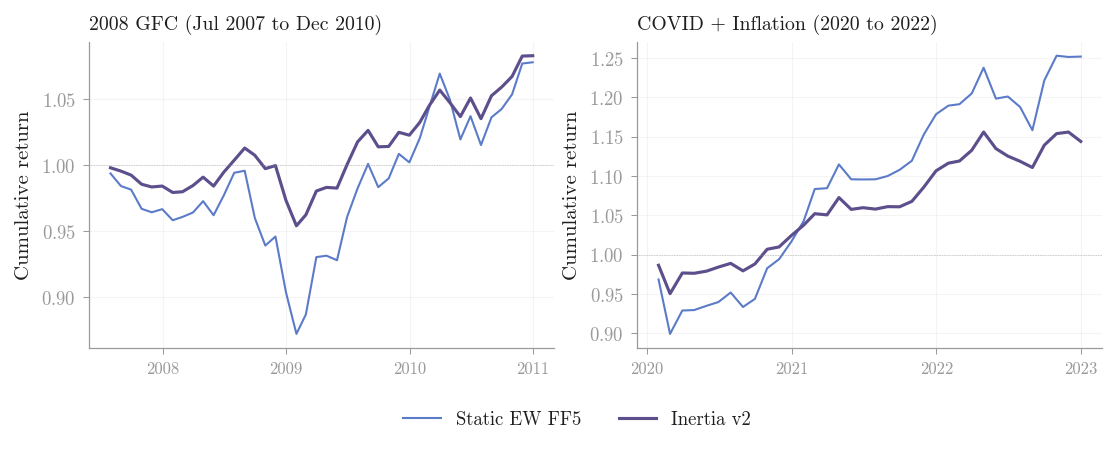

  saved: ../figures/19_inertia_crisis_zoom.png


In [9]:
import matplotlib
import matplotlib.dates as mdates
with matplotlib.rc_context({'figure.constrained_layout.use': False}):
    fig, axes = plt.subplots(1, 2, figsize=(FULL_COL, 3.0))
    panels = [('2007-07', '2010-12', '2008 GFC (Jul 2007 to Dec 2010)'),
              ('2020-01', '2022-12', 'COVID + Inflation (2020 to 2022)')]
    for ax, (s, e, label) in zip(axes, panels):
        for name, color, lw in [
            ('Static EW FF5', C['blue'],   1.0),
            ('Inertia v2',    C['purple'], 1.5),
        ]:
            slc = final[name].loc[s:e]
            cum = (1 + slc).cumprod()
            ax.plot(cum.index, cum.values, color=color, linewidth=lw,
                    label=name if ax is axes[0] else None)
        ax.axhline(1, color=C['muted'], linewidth=0.3, linestyle=':')
        ax.set_title(label, loc='left', color=C['ink'], fontsize=9.5)
        ax.set_ylabel('Cumulative return')
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        for t in ax.get_xticklabels(): t.set_fontsize(8)
    axes[0].legend(frameon=False, loc='upper center',
                   bbox_to_anchor=(1.05, -0.15), ncol=2, fontsize=9)
    fig.subplots_adjust(left=0.08, right=0.98, wspace=0.18, top=0.90, bottom=0.22)
    fig.savefig(f'{FIG_DIR}/19_inertia_crisis_zoom.png', dpi=300, bbox_inches='tight', pad_inches=0.10)
    plt.show()
    print(f'  saved: {FIG_DIR}/19_inertia_crisis_zoom.png')

## 7. Subsample Sharpe by decade

In [10]:
decades = {
    '1990s':     ('1990-01', '1999-12'),
    '2000s':     ('2000-01', '2009-12'),
    '2010s':     ('2010-01', '2019-12'),
    '2020-2026': ('2020-01', None),
}
rows = {}
for name, r in final.items():
    sub = {}
    for label, (lo, hi) in decades.items():
        rr = r.loc[lo:hi].dropna()
        if len(rr) < 12:
            sub[label] = np.nan
        else:
            mu = rr.mean() * 12; sd = rr.std(ddof=1) * np.sqrt(12)
            sub[label] = mu / sd if sd > 0 else np.nan
    rows[name] = sub
decade_sharpe = pd.DataFrame(rows).T
save_table(decade_sharpe, '26_final_subsample_sharpe', out_dir=TABLE_DIR)
decade_sharpe

  saved: ../tables/26_final_subsample_sharpe.{csv,md}


,1990s,2000s,2010s,2020-2026
Static EW FF5,0.8927,1.0599,0.5057,0.5782
Method A,0.4610,0.4315,-0.0987,-0.2019
Method B,0.8992,0.5025,0.3108,0.7175
Method C,0.2663,0.2734,0.2820,0.3597
Pure ensemble,0.6584,0.5036,0.1015,0.0851
Inertia v2,0.9339,1.1350,0.5612,0.6429


In [11]:
fig, ax = plt.subplots(figsize=(FULL_COL, 3.6))
x = np.arange(len(decades))
names_for_bars = ['Static EW FF5', 'Method C', 'Inertia v2']
w = 0.26
for i, name in enumerate(names_for_bars):
    pos = x + (i - 1) * w
    ax.bar(pos, decade_sharpe.loc[name].values, w,
           color=colors_map[name], label=name, edgecolor='white', linewidth=0.4)
ax.axhline(0, color=C['muted'], linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(list(decades.keys()), fontsize=10)
ax.set_ylabel('Annualized Sharpe ratio')
ax.set_title('Decade Sharpe: Inertia v2 holds up across regimes',
             loc='left', color=C['ink'])
legend_below(ax, ncol=3)
save_fig(fig, '20_final_subsample_bars', out_dir=FIG_DIR)
plt.show()

  saved: ../figures/20_final_subsample_bars.png


## 8. Save Inertia v2 returns for Sprint 4

In [12]:
r_inertia.to_csv(f'{TABLE_DIR}/27_inertia_v2_returns.csv')
print(f'Saved Inertia v2 returns: {len(r_inertia)} months.')

Saved Inertia v2 returns: 433 months.


## Takeaways for Sprint 3 (revised)

- **Pure timing approaches do not beat static FF5.** Methods A, B, C and the equal-weight ensemble all underperform on Sharpe.
- **The defensive hybrid does.** A 50/50 blend of static FF5 and the GBM-based Method C lifts Sharpe from 0.74 to 0.80, with vol cut from 4.9 percent to 2.6 percent and max drawdown nearly halved.
- The improvement is **economically meaningful but not statistically significant** at the 5 percent level (the paired bootstrap CI on Sharpe difference includes zero).
- The story to pitch: **Inertia v2 is a defensive overlay**. It preserves most of the static FF5 risk premium while materially reducing drawdown and volatility through a regime-aware ML signal. This is a risk-management value proposition, not a pure alpha pitch.